In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE

import joblib

In [3]:
# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe(include="all"))

Dataset Shape:
(891, 15)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Statistical Summary:
          survived      p

In [5]:
# Calculate missing value percentages
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Show only columns with missing values
missing_percentage = missing_percentage[missing_percentage > 0]

print("Missing Value Percentages:")
print(missing_percentage.sort_values(ascending=False))

Missing Value Percentages:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [6]:
# Save dataset as offline fallback
df.to_csv(
    "titanic.csv",
    index=False
)

print("titanic.csv saved successfully!")

titanic.csv saved successfully!


In [7]:
# Create a copy of the dataset
df_clean = df.copy()

# 1. Drop 'deck' (more than 30% missing values)
df_clean.drop(columns=["deck"], inplace=True)

# 2. Impute missing values in 'age' with the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# 3. Drop rows with missing embarked and embark_town
df_clean.dropna(subset=["embarked", "embark_town"], inplace=True)

# Check remaining missing values
print("Remaining Missing Values:")
print(df_clean.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(df_clean.shape)

Remaining Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Dataset Shape After Cleaning:
(889, 14)


In [8]:
df_clean.to_csv("titanic_cleaned.csv", index=False)

print("titanic_cleaned.csv saved successfully!")

titanic_cleaned.csv saved successfully!


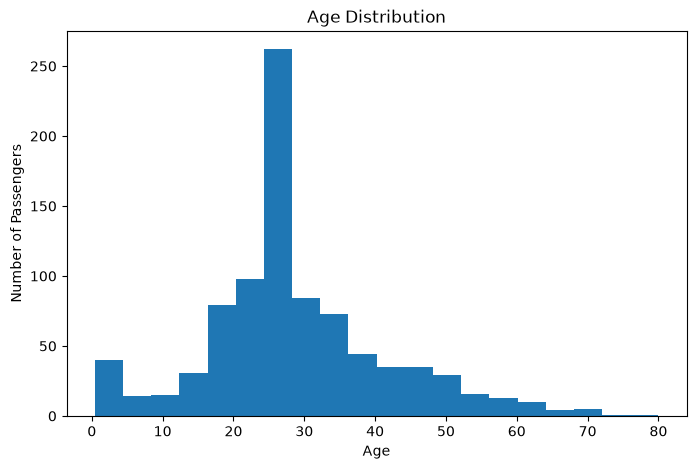

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

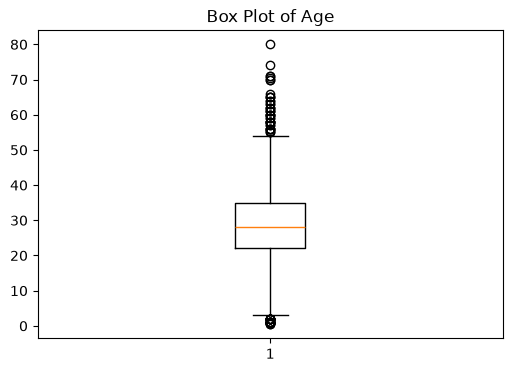

In [10]:
plt.figure(figsize=(6,4))

plt.boxplot(df_clean["age"])

plt.title("Box Plot of Age")

plt.show()

In [11]:
print("Age Statistics")

print("Mean   :", df_clean["age"].mean())
print("Median :", df_clean["age"].median())
print("Mode   :", df_clean["age"].mode()[0])

Age Statistics
Mean   : 29.315151856017994
Median : 28.0
Mode   : 28.0


In [12]:
Q1 = df_clean["age"].quantile(0.25)
Q3 = df_clean["age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["age"] < lower_limit) |
    (df_clean["age"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 65


In [13]:
mean_age = df_clean["age"].mean()
median_age = df_clean["age"].median()

print("Mean :", mean_age)
print("Median :", median_age)

if mean_age > median_age:
    print("Age is Right Skewed")

elif mean_age < median_age:
    print("Age is Left Skewed")

else:
    print("Age is Approximately Symmetric")

Mean : 29.315151856017994
Median : 28.0
Age is Right Skewed


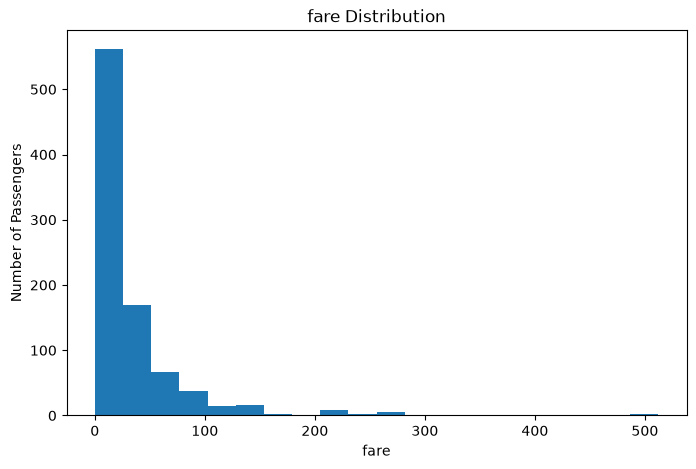

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["fare"], bins=20)

plt.title("fare Distribution")
plt.xlabel("fare")
plt.ylabel("Number of Passengers")

plt.show()

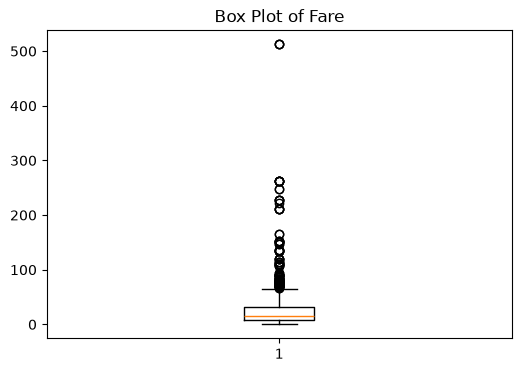

In [15]:
plt.figure(figsize=(6,4))

plt.boxplot(df_clean["fare"])

plt.title("Box Plot of Fare")

plt.show()

In [16]:
print("Fare Statistics")

print("Mean   :", df_clean["fare"].mean())
print("Median :", df_clean["fare"].median())
print("Mode   :", df_clean["fare"].mode()[0])

Fare Statistics
Mean   : 32.09668087739032
Median : 14.4542
Mode   : 8.05


In [17]:
Q1 = df_clean["fare"].quantile(0.25)
Q3 = df_clean["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["fare"] < lower_limit) |
    (df_clean["fare"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 114


In [18]:
mean_fare = df_clean["fare"].mean()
median_fare = df_clean["fare"].median()
mode_fare = df_clean["fare"].mode()[0]

print("Mean :", mean_fare)
print("Median :", median_fare)
print("Mode :", mode_fare)

if mean_fare > median_fare > mode_fare:
    print("Fare is Right Skewed")

elif mean_fare < median_fare < mode_fare:
    print("Fare is Left Skewed")

else:
    print("fare is Approximately Symmetric")

Mean : 32.09668087739032
Median : 14.4542
Mode : 8.05
Fare is Right Skewed


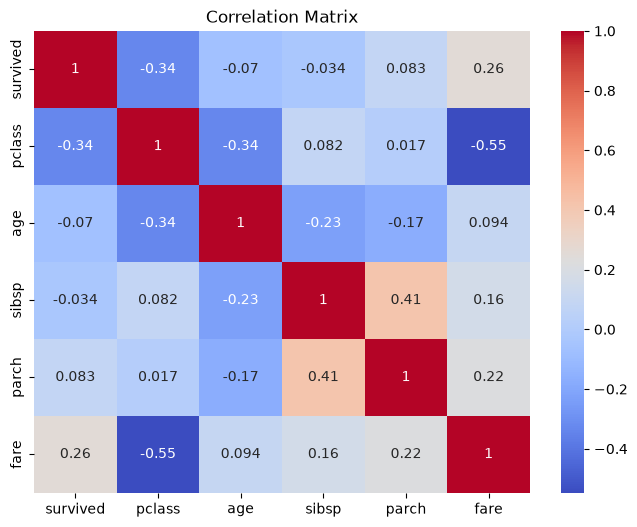

In [19]:
corr_df = df_clean[
    [
        "survived",
        "pclass",
        "age",
        "sibsp",
        "parch",
        "fare"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

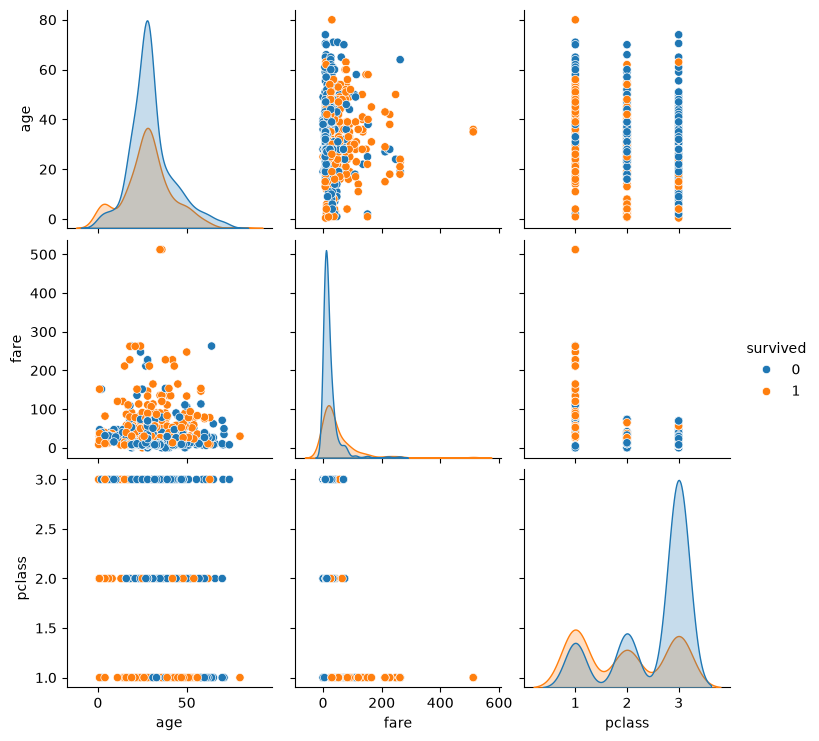

In [20]:
sns.pairplot(
    df_clean[
        [
            "survived",
            "age",
            "fare",
            "pclass"
        ]
    ],
    hue="survived"
)

plt.show()

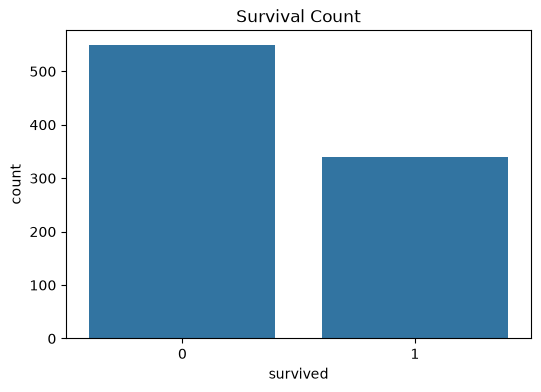

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="survived",
    data=df_clean
)

plt.title("Survival Count")

plt.show()

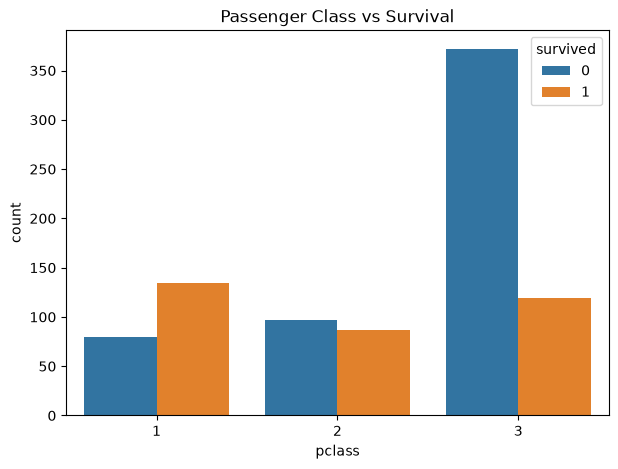

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="pclass",
    hue="survived",
    data=df_clean
)

plt.title("Passenger Class vs Survival")

plt.show()

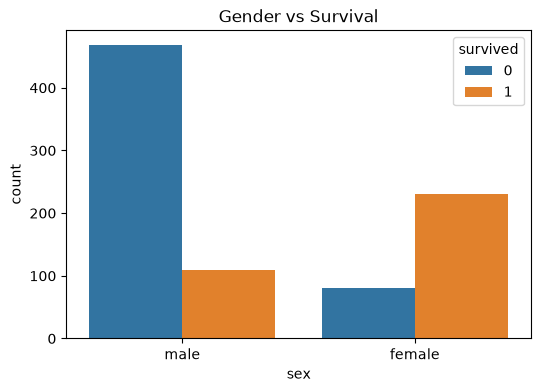

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="sex",
    hue="survived",
    data=df_clean
)

plt.title("Gender vs Survival")

plt.show()

In [24]:
print("Survival Rate by Sex")
print(df_clean.groupby("sex")["survived"].mean())

print("\nSurvival Rate by Passenger Class")
print(df_clean.groupby("pclass")["survived"].mean())

print("\nSurvival Rate by Sex and Passenger Class")
print(df_clean.groupby(["sex", "pclass"])["survived"].mean())

Survival Rate by Sex
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival Rate by Passenger Class
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival Rate by Sex and Passenger Class
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


In [25]:
from sklearn.preprocessing import StandardScaler

print("Before Standardization")
print(df_clean[["age", "fare"]].agg(["mean", "std"]))

scaler = StandardScaler()

df_scaled = df_clean.copy()

df_scaled[["age", "fare"]] = scaler.fit_transform(
    df_scaled[["age", "fare"]]
)

print("\nAfter Standardization")
print(df_scaled[["age", "fare"]].agg(["mean", "std"]))

Before Standardization
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


In [44]:
# Input features
X = df_clean.drop(columns=["survived", "alive"])

# Target variable
y = df_clean["survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (889, 12)
Target Shape: (889,)


In [45]:
# Numeric columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numeric Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

Numeric Features
Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

Categorical Features
Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town',
       'alone'],
      dtype='str')


In [46]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (711, 12)
Testing Set  : (178, 12)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8146067415730337
Precision: 0.7966101694915254
Recall   : 0.6911764705882353
F1 Score : 0.7401574803149606

Confusion Matrix
[[98 12]
 [21 47]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.69      0.74        68

    accuracy                           0.81       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.81      0.81       178



In [52]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_pipeline.fit(X_train, y_train)

y_pred_dt = decision_tree_pipeline.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8033707865168539

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



In [53]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

random_forest_pipeline.fit(X_train, y_train)

y_pred_rf = random_forest_pipeline.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7696629213483146

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.71      0.66      0.69        68

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.75       178
weighted avg       0.77      0.77      0.77       178



In [54]:
from imblearn.over_sampling import SMOTE

# Transform training data
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original Training Shape:", X_train_processed.shape)
print("Balanced Training Shape:", X_train_smote.shape)

Original Training Shape: (711, 23)
Balanced Training Shape: (878, 23)


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a pipeline that includes preprocessing and the Random Forest classifier
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, oob_score=True, bootstrap=True))
])

# Hyperparameter grid, adjusted for the pipeline structure
param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__max_features": ["sqrt", "log2"]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_pipeline, # Use the pipeline as the estimator
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred_best = best_model.predict(X_test)

# Results
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

# Accessing OOB score from the best_model's classifier
# Note: oob_score_ is only available if bootstrap=True and oob_score=True were set.
# Since we set it in the pipeline's RandomForestClassifier, we can access it.
print("\nOut-of-Bag (OOB) Score:")
print(best_model.named_steps['classifier'].oob_score_)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross Validation Score:
0.8199448438885059

Out-of-Bag (OOB) Score:
0.819971870604782

Test Accuracy:
0.8202247191011236

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.83      0.66      0.74        68

    accuracy                           0.82       178
   macro avg       0.82      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178



In [56]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Best Model Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

Best Model Accuracy: 0.8202247191011236

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.83      0.66      0.74        68

    accuracy                           0.82       178
   macro avg       0.82      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178



In [57]:
from sklearn.linear_model import LinearRegression

# Features for regression
X_reg = df_clean.drop(columns=["fare"])

# Target
y_reg = df_clean["fare"]

# Convert categorical columns to dummy variables
X_reg = pd.get_dummies(X_reg, drop_first=True)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

y_pred_reg = linear_model.predict(X_test_reg)

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE :", mean_squared_error(y_test_reg, y_pred_reg))
print("RMSE:", mean_squared_error(
    y_test_reg,
    y_pred_reg
) ** 0.5)
print("R2 Score:", r2_score(
    y_test_reg,
    y_pred_reg
))

MAE : 18.37354211109449
MSE : 1705.0395147693346
RMSE: 41.292124125180756
R2 Score: 0.36091622223508857


In [59]:
import joblib

joblib.dump(
    best_model,
    "best_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!
